In [1]:
# --! include root folder into PYTHONPATH ---------------------------------!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

In [2]:
# --! import Python libraries and KIND framework files -------------------!

import numpy as np

import utils_detuning
import utils_data

# Generating cavity data via simulations

In [3]:
# --! instatiate a cavity simulator ------------------------------------------------------!

config = {
    'q_rf'       : 4e7,        # loaded quality factor
    'f_rf'       : 1.3e9,      # cavity frequency in hertz
    'v_rf'       : [10., 0.],  # generator voltage
    'pctr_on_rf' : True,       # prortional controller is on
    'K_rf'       : 100.        # proportional controller gain
}

sim = utils_detuning.detuning_sim(config)

inf >> half-bandwidth of this radio frequency cavity is 16.25 Herz
inf >> cavity filling time is 0.06 seconds


In [4]:
# --! define data general parameters ------------------------------------------------------!

dt = 0.01 # discretization step
ns = 0.01 # rms noise level

### Stationary data to train KIND stationary operator

inf >> number of mechanical modes specified: 1


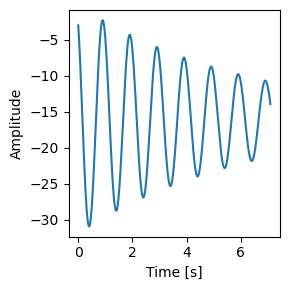

inf >> training files saved


In [5]:
# --! simulate with parameters -----------------------------------------------!

# --! define a list of simulation parameters
sim_param = [
    {
        'f_m'    : np.array([1.]),
        'q_m'    : np.array([20.]),
        't_m'    : np.array([[-1., -1.]]),
        't_rf_n' : 120,
        'dt'     : dt,
    },
]

stadets_sca = sim(sim_param, noise=ns)

# --! display resulting detuning
for det in stadets_sca:
    sim.disp(det, timestep=dt)

# --! save timeseries
savedata_on      = True
savedata_dir     = '../../data/kalman/train_sim_sta'
savedata_nsample = 200
if savedata_on:
    utils_data.save_traindata(stadets_sca, savedata_dir, savedata_nsample)
else:
    print('wrn >> global training file saving is switched off')

### Transient data to train KIND transient operator

inf >> number of mechanical modes specified: 2
inf >> number of mechanical modes specified: 2
inf >> number of mechanical modes specified: 2
inf >> number of mechanical modes specified: 2
inf >> number of mechanical modes specified: 2
inf >> number of mechanical modes specified: 2
inf >> number of mechanical modes specified: 2
inf >> number of mechanical modes specified: 2
inf >> number of mechanical modes specified: 2
inf >> number of mechanical modes specified: 2


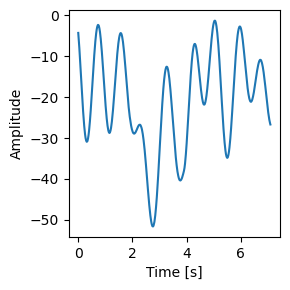

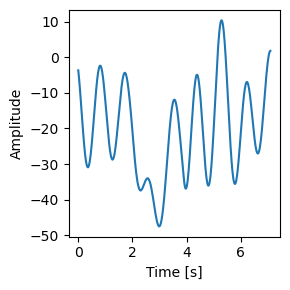

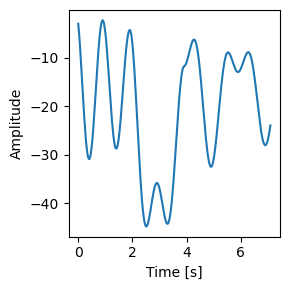

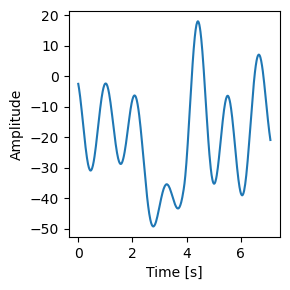

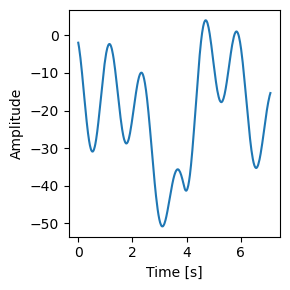

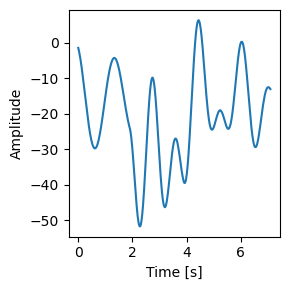

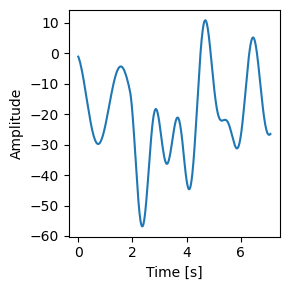

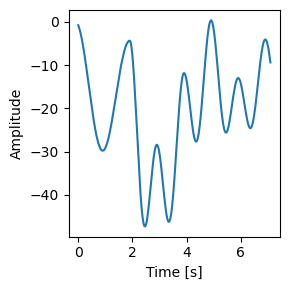

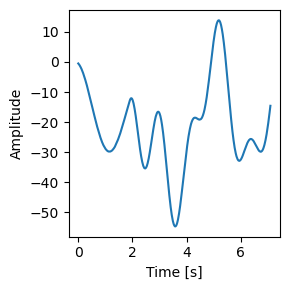

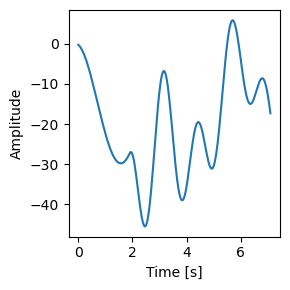

inf >> training files saved


In [6]:
# --! simulate with parameters -----------------------------------------------!

sim_param = [
    # --! transtions with decreasing frequency between 2 and 4 seconds
    {
        'f_m'    : np.array([1.2, 0.7]),
        'q_m'    : np.array([20., 10.]),
        't_m'    : np.array([[-1., 4.0], [2.0, -1.]]),
        't_rf_n' : 120,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([1.1, 0.6]),
        'q_m'    : np.array([20., 10.]),
        't_m'    : np.array([[-1., 4.0], [2.0, -1.]]),
        't_rf_n' : 120,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([1.0, 0.5]),
        'q_m'    : np.array([20., 10.]),
        't_m'    : np.array([[-1., 4.0], [2.0, -1.]]),
        't_rf_n' : 120,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([0.9, 0.4]),
        'q_m'    : np.array([20., 10.]),
        't_m'    : np.array([[-1, 4.0], [2.0, -1]]),
        't_rf_n' : 120,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([0.8, 0.3]),
        'q_m'    : np.array([20., 10.]),
        't_m'    : np.array([[-1, 4.0], [2.0, -1]]),
        't_rf_n' : 120,
        'dt'     : dt,
    },

    # --! transtions with increasing frequency between 2 and 4 seconds
    {
        'f_m'    : np.array([0.7, 1.2]),
        'q_m'    : np.array([10., 20.]),
        't_m'    : np.array([[-1., 4.0], [2.0, -1.]]),
        't_rf_n' : 120,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([0.6, 1.1]),
        'q_m'    : np.array([10., 20.]),
        't_m'    : np.array([[-1., 4.0], [2.0, -1.]]),
        't_rf_n' : 120,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([0.5, 1.0]),
        'q_m'    : np.array([10., 20.]),
        't_m'    : np.array([[-1., 4.0], [2.0, -1.]]),
        't_rf_n' : 120,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([0.4, 0.9]),
        'q_m'    : np.array([10., 20.]),
        't_m'    : np.array([[-1, 4.0], [2.0, -1]]),
        't_rf_n' : 120,
        'dt'     : dt,
    },
    {
        'f_m'    : np.array([0.3, 0.8]),
        'q_m'    : np.array([10., 20.]),
        't_m'    : np.array([[-1, 4.0], [2.0, -1]]),
        't_rf_n' : 120,
        'dt'     : dt,
    },
]

transdets_sca = sim(sim_param, noise=ns)

# --! display resulting detuning
for det in transdets_sca:
    sim.disp(det, timestep=dt)

# --! save timeseries
savedata_on      = True
savedata_dir     = '../../data/kalman/train_sim_dyn'
savedata_nsample = 200
if savedata_on:
    utils_data.save_traindata(transdets_sca, savedata_dir, savedata_nsample)
else:
    print('wrn >> local training file saving is switched off')

### Mix of stationary and transient data to train the variance of KIND operators

In [7]:
# --! compose and save mixed timeseries
savedata_on      = True
savedata_dir     = '../../data/kalman/train_sim_mix'
savedata_nsample = 200
mixdets_sca      = stadets_sca + transdets_sca
if savedata_on:
    utils_data.save_traindata(mixdets_sca, savedata_dir, savedata_nsample)
else:
    print('wrn >> local training file saving is switched off')

inf >> training files saved


### Evaluation data

inf >> number of mechanical modes specified: 2


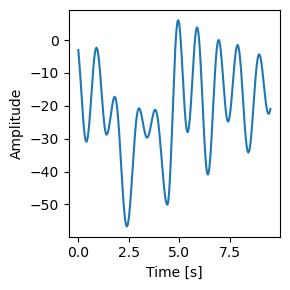

inf >> evaluation file saved


In [8]:
# --! simulate with parameters -----------------------------------------------!

sim_param = [
    {
        'f_m'    : np.array([1.0, 0.5]),
        'q_m'    : np.array([20., 10.]),
        't_m'    : np.array([[-1., 4.5], [1.5, -1.]]),
        't_rf_n' : 160,
        'dt'     : dt,
    }
]

testdets_sca = sim(sim_param, noise=ns)

# --! display resulting detuning
for det in testdets_sca:
    sim.disp(det, timestep=dt)

# --! save timeseries
savedata_on      = True
savedata_dir     = '../../data/kalman/test_sim'
savedata_nsample = 200
if savedata_on:
    utils_data.save_testdata(testdets_sca, savedata_dir, savedata_nsample)
else:
    print('wrn >> local training file saving is switched off')